# Air Quality Dataset for Nairobi

This data set contains PM (particulate matter), temperature, and humidity readings taken with low-cost sensors. These sensors measure the concentration of PM in the air, including particles with diameters less than or equal to 1 micrometer (PM1), 2.5 micrometers (PM2.5), and particles with diameters less than or equal to 10 micrometers (PM10). The data set includes information on the sensor type, date, time, and location of the readings, as well as the sensor’s specific measurement values for Temperature (C), Humidity (%), PM1, PM2.5, and PM10. The data set is ideal for researchers and individuals interested in studying air quality and low-cost sensors in PM measurement. The dataset is stored in CSV format and can be opened using editors like Microsoft Excel, Google Sheets, LibreOffice Calc, etc. Note that P0 in the data represents PM1, P2 represents PM2.5, and P1 represents PM10.

In [1]:
import pandas as pd
import requests
import io
import os

In [2]:
dataset_urls = ["https://open.africa/dataset/44359020-b2b0-4b66-af09-3de18d6519dc/resource/bc6de77a-ca62-4836-956d-fb740097ae96/download/january_2018_sensor_data_archive.csv",
                "https://open.africa/dataset/44359020-b2b0-4b66-af09-3de18d6519dc/resource/5420158e-570e-4d9a-9f2b-dc9e783e62d4/download/february_2018_sensor_data_archive.csv",
                "https://open.africa/dataset/44359020-b2b0-4b66-af09-3de18d6519dc/resource/e0b317f5-3344-4947-b0b4-2913c892a000/download/march_2018_sensor_data_archive.csv"]

In [3]:
os.makedirs('data', exist_ok=True)

for url in dataset_urls:
  filename = url.split("/")[-1]
  filepath = f'data/{filename}'
  print(f'Downloading {url} to {filepath}')
  response = requests.get(url)
  with open(filepath, 'wb') as f:
    for chuck in response.iter_content(chunk_size=8192):
      f.write(chuck)
      # f.write(response.content)
  print(f'Saved: {filepath}\n')

Saved: data/january_2018_sensor_data_archive.csv

Saved: data/february_2018_sensor_data_archive.csv

Saved: data/march_2018_sensor_data_archive.csv



In [4]:
jan_dt = pd.read_csv('data/january_2018_sensor_data_archive.csv', delimiter=';')
feb_dt = pd.read_csv('data/february_2018_sensor_data_archive.csv', delimiter=';')
mar_dt = pd.read_csv('data/march_2018_sensor_data_archive.csv', delimiter=';')

In [5]:
print(jan_dt.shape)
print(feb_dt.shape)
print(mar_dt.shape)

(103042, 8)
(140408, 8)
(147038, 8)


In [6]:
df1 = jan_dt.copy()
df2 = feb_dt.copy()
df3 = mar_dt.copy()

In [7]:
df = pd.concat([df1, df2, df3]).reset_index(drop=True)

df.shape
df.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,3,SDS011,16,-1.288,36.841,2018-01-01T00:02:00.522075+00:00,P2,12.4
1,3,SDS011,16,-1.288,36.841,2018-01-01T00:02:00.522075+00:00,P1,27.2
2,3,SDS011,16,-1.288,36.841,2018-01-01T00:02:09.561058+00:00,P2,12.4
3,3,SDS011,16,-1.288,36.841,2018-01-01T00:02:09.561058+00:00,P1,27.2
4,24,DHT22,16,-1.288,36.841,2018-01-01T00:02:18.891954+00:00,humidity,55.7


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390488 entries, 0 to 390487
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    390488 non-null  int64  
 1   sensor_type  390488 non-null  object 
 2   location     390488 non-null  int64  
 3   lat          390488 non-null  float64
 4   lon          390488 non-null  float64
 5   timestamp    390488 non-null  object 
 6   value_type   390488 non-null  object 
 7   value        390488 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 23.8+ MB


In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [10]:
from datetime import datetime as dt
today = dt.now
today

<function datetime.now(tz=None)>

In [11]:
# feature engineering - time-based features

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['is_weekend'] = (df['dayofweek']>=5).astype(int)
df['is_rush_hour'] = df['hour'].isin([7,8,9,10,16,17,18,19]).astype(int)

In [12]:
# lag features




In [13]:
df['value_type'].unique()

array(['P2', 'P1', 'humidity', 'temperature'], dtype=object)

In [14]:
# Create subsets based on value_type
pm10 = df[df['value_type'] == 'P1'].copy()
pm25 = df[df['value_type'] == 'P2'].copy()
humidity_df = df[df['value_type'] == 'humidity'].copy()
temp_df = df[df['value_type'] == 'temperature'].copy()

subsets = {
    'pm10': pm10,
    'pm25': pm25,
    'humidity_df': humidity_df,
    'temp_df': temp_df
}

In [15]:
print('--- PM10 ---')
print(f'Shape: {pm10.shape}')
print(f'Missing values: {pm10["value"].isnull().sum()}')

print('\n--- PM25 ---')
print(f'Shape: {pm25.shape}')
print(f'Missing values: {pm25["value"].isnull().sum()}')

print('\n--- Humidity ---')
print(f'Shape: {humidity_df.shape}')
print(f'Missing values: {humidity_df["value"].isnull().sum()}')

print('\n--- Temperature ---')
print(f'Shape: {temp_df.shape}')
print(f'Missing values: {temp_df["value"].isnull().sum()}')

--- PM10 ---
Shape: (100071, 14)
Missing values: 0

--- PM25 ---
Shape: (100071, 14)
Missing values: 0

--- Humidity ---
Shape: (95173, 14)
Missing values: 0

--- Temperature ---
Shape: (95173, 14)
Missing values: 0


In [16]:
subsets_to_check = {"PM10": pm10, "PM25": pm25, "Humidity": humidity_df, "Temperature": temp_df}

for name, subset in subsets_to_check.items():
    Q1 = subset['value'].quantile(0.25)
    Q3 = subset['value'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = subset[(subset['value'] < lower_bound) | (subset['value'] > upper_bound)]

    print(f"--- {name} Outliers ---")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Total Outliers: {len(outliers)}")
    print(f"Percentage: {(len(outliers)/len(subset))*100:.2f}%")
    print("-" * 30)

--- PM10 Outliers ---
Lower Bound: -14.07, Upper Bound: 60.33
Total Outliers: 6158
Percentage: 6.15%
------------------------------
--- PM25 Outliers ---
Lower Bound: -7.47, Upper Bound: 27.57
Total Outliers: 9218
Percentage: 9.21%
------------------------------
--- Humidity Outliers ---
Lower Bound: 14.55, Upper Bound: 96.55
Total Outliers: 0
Percentage: 0.00%
------------------------------
--- Temperature Outliers ---
Lower Bound: 16.35, Upper Bound: 28.75
Total Outliers: 2313
Percentage: 2.43%
------------------------------


In [17]:
#  check how many negative values exist in PM10 and PM25 specifically
print((pm10['value'] < 0).sum())
print((pm25['value'] < 0).sum())

0
0


In [18]:
print("Descriptive statistics for PM10 'value' column:")
print(pm10['value'].describe())
print("\nDescriptive statistics for PM25 'value' column:")
print(pm25['value'].describe())

Descriptive statistics for PM10 'value' column:
count    100071.000000
mean         28.021295
std          31.252605
min           1.170000
25%          13.830000
50%          21.230000
75%          32.430000
max        1685.770000
Name: value, dtype: float64

Descriptive statistics for PM25 'value' column:
count    100071.000000
mean         13.368267
std          16.836235
min           0.700000
25%           5.670000
50%           9.070000
75%          14.430000
max         628.630000
Name: value, dtype: float64


The WHO guideline for PM10 is 45 µg/m³.
The WHO 24-hour guideline for PM2.5 is 15 µg/m³.

In [19]:
# Apply capping to PM10 and PM25 values to keep timeline intact
pm10['value'] = pm10['value'].clip(upper=60.33)
pm25['value'] = pm25['value'].clip(upper=27.57)

In [20]:
print("PM10 'value' column after capping:")
print(pm10['value'].describe())

print("\nPM25 'value' column after capping:")
print(pm25['value'].describe())

PM10 'value' column after capping:
count    100071.000000
mean         25.000725
std          14.939416
min           1.170000
25%          13.830000
50%          21.230000
75%          32.430000
max          60.330000
Name: value, dtype: float64

PM25 'value' column after capping:
count    100071.000000
mean         11.218802
std           7.501408
min           0.700000
25%           5.670000
50%           9.070000
75%          14.430000
max          27.570000
Name: value, dtype: float64


In [21]:
temp_df['value'].describe()

,value
count,95173.000000
mean,22.824192
std,2.502489
min,16.900000
25%,21.000000
50%,22.500000
75%,24.100000
max,37.800000


In [22]:
pm10 = pm10.set_index('timestamp')
pm25 = pm25.set_index('timestamp')
humidity_df = humidity_df.set_index('timestamp')
temp_df = temp_df.set_index('timestamp')

In [23]:
print(pm10.index)

DatetimeIndex(['2018-01-01 00:02:00.522075+00:00',
               '2018-01-01 00:02:09.561058+00:00',
               '2018-01-01 00:05:13.601185+00:00',
               '2018-01-01 00:05:22.912776+00:00',
               '2018-01-01 00:08:26.672641+00:00',
               '2018-01-01 00:08:35.563974+00:00',
               '2018-01-01 00:11:40.102619+00:00',
               '2018-01-01 00:11:49.389919+00:00',
               '2018-01-01 00:14:55.744055+00:00',
               '2018-01-01 00:15:04.688773+00:00',
               ...
               '2018-03-31 23:34:07.104702+00:00',
               '2018-03-31 23:36:38.269470+00:00',
               '2018-03-31 23:39:14.694302+00:00',
               '2018-03-31 23:41:47.256370+00:00',
               '2018-03-31 23:44:16.157289+00:00',
               '2018-03-31 23:46:47.515998+00:00',
               '2018-03-31 23:51:55.350540+00:00',
               '2018-03-31 23:54:25.797927+00:00',
               '2018-03-31 23:56:57.825816+00:00',
            

In [24]:
pm10.index = pm10.index.tz_localize(None)
pm25.index = pm25.index.tz_localize(None)
humidity_df.index = humidity_df.index.tz_localize(None)
temp_df.index = temp_df.index.tz_localize(None)

In [30]:
import matplotlib.pyplot as plt

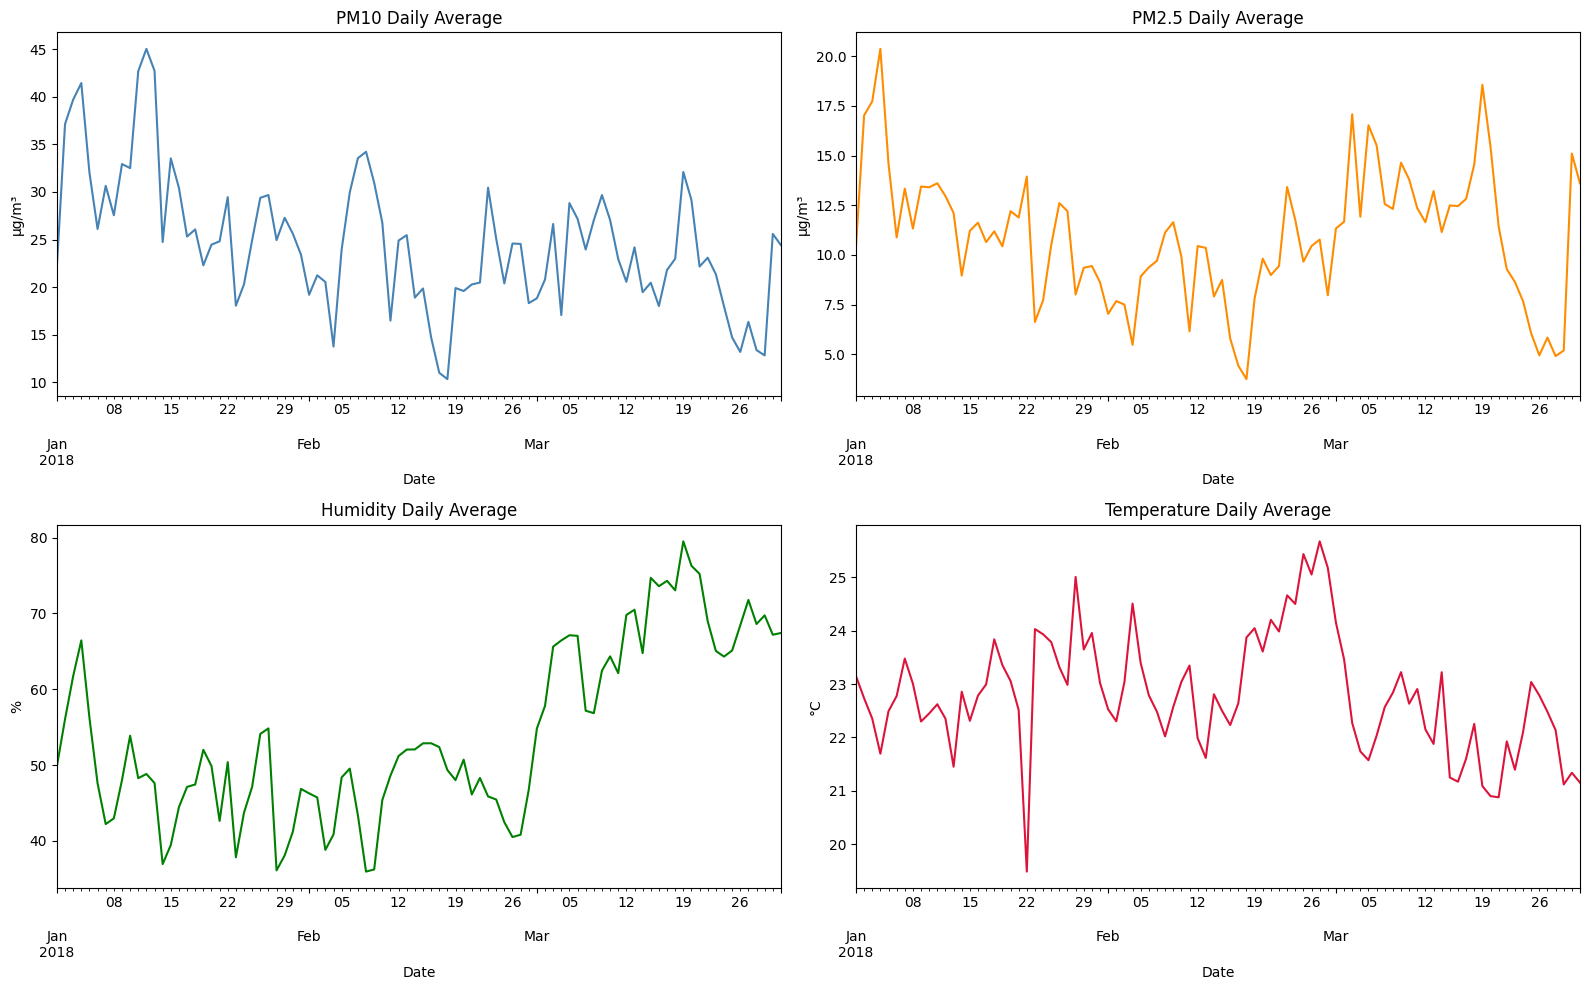

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pm10['value'].resample('D').mean().plot(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('PM10 Daily Average')
axes[0,0].set_ylabel('µg/m³')
axes[0,0].set_xlabel('Date')

pm25['value'].resample('D').mean().plot(ax=axes[0,1], color='darkorange')
axes[0,1].set_title('PM2.5 Daily Average')
axes[0,1].set_ylabel('µg/m³')
axes[0,1].set_xlabel('Date')

humidity_df['value'].resample('D').mean().plot(ax=axes[1,0], color='green')
axes[1,0].set_title('Humidity Daily Average')
axes[1,0].set_ylabel('%')
axes[1,0].set_xlabel('Date')

temp_df['value'].resample('D').mean().plot(ax=axes[1,1], color='crimson')
axes[1,1].set_title('Temperature Daily Average')
axes[1,1].set_ylabel('°C')
axes[1,1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [33]:
plt.savefig('air_quality_four_panel.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>